In [1]:
# install BLADE with !pip install iohblade

from iohblade.loggers import ExperimentLogger
from iohblade.plots import plot_convergence, plot_experiment_CEG, plot_boxplot_fitness_hue
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json


def plot_landscape(row, bounds=(-5, 5), res=200):
    """
    row  : one row of the dataframe (df.loc[idx] or df.iloc[idx])
    bounds: (low, high) tuple applied to both axes
    res   : grid resolution per axis
    """
    # Re-create the callable from the code string
    ns = {}
    exec(row["code"], ns)                      # defines class with same name as row["name"]
    f   = getattr(ns[row["name"]](dim=2), "f")      # instantiate & grab its .f method

    # Grid
    x = np.linspace(bounds[0], bounds[1], res)
    y = np.linspace(bounds[0], bounds[1], res)
    X, Y = np.meshgrid(x, y)
    pts   = np.stack([X.ravel(), Y.ravel()], axis=1)
    Z     = np.apply_along_axis(f, 1, pts).reshape(X.shape)   # robust fallback

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    cs = ax.contourf(X, Y, Z, levels=50, cmap="viridis")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Landscape of {row['name']}")
    plt.colorbar(cs, ax=ax, label="f(x)")
    plt.tight_layout()
    return fig, ax

logger = ExperimentLogger('../results/ELA_novelty_3_local', True)
# logger.add_read_dir('../results/kerneltuner-o4')
# logger.add_read_dir('../results/kerneltuner-o4-no-info')

/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
methods, problems = logger.get_methods_problems()
print(methods)
print(problems)
len(problems)



['LLaMEA-multi-llm']
['GlobalLocal_Multimodality', 'Separable_Basins', 'GlobalLocal_Homogeneous', 'Basins_Homogeneous', 'NOT Homogeneous_Separable', 'Basins', 'NOT Basins', 'NOT Homogeneous', 'GlobalLocal_Basins', 'NOT Homogeneous_GlobalLocal', 'Separable', 'Homogeneous', 'NOT Homogeneous_Multimodality', 'Separable_Multimodality', 'Separable_GlobalLocal', 'NOT Basins_Multimodality', 'GlobalLocal', 'NOT Basins_Separable', 'Multimodality', 'Multimodality_Homogeneous', 'Multimodality_Basins', 'NOT Basins_GlobalLocal', 'Separable_Homogeneous']


23

Skipped: Problem: Basins, data points: 1


<>:45: SyntaxWarning: invalid escape sequence '\h'
<>:45: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3847767/1466035543.py:45: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel("Percentage with $\hat{F} > 0.5$", fontsize=14)


Skipped: Problem: GlobalLocal_Basins, data points: 0
Skipped: Problem: NOT Basins, data points: 1
Skipped: Problem: NOT Basins_Multimodality, data points: 10
Skipped: Problem: Separable_Homogeneous, data points: 0


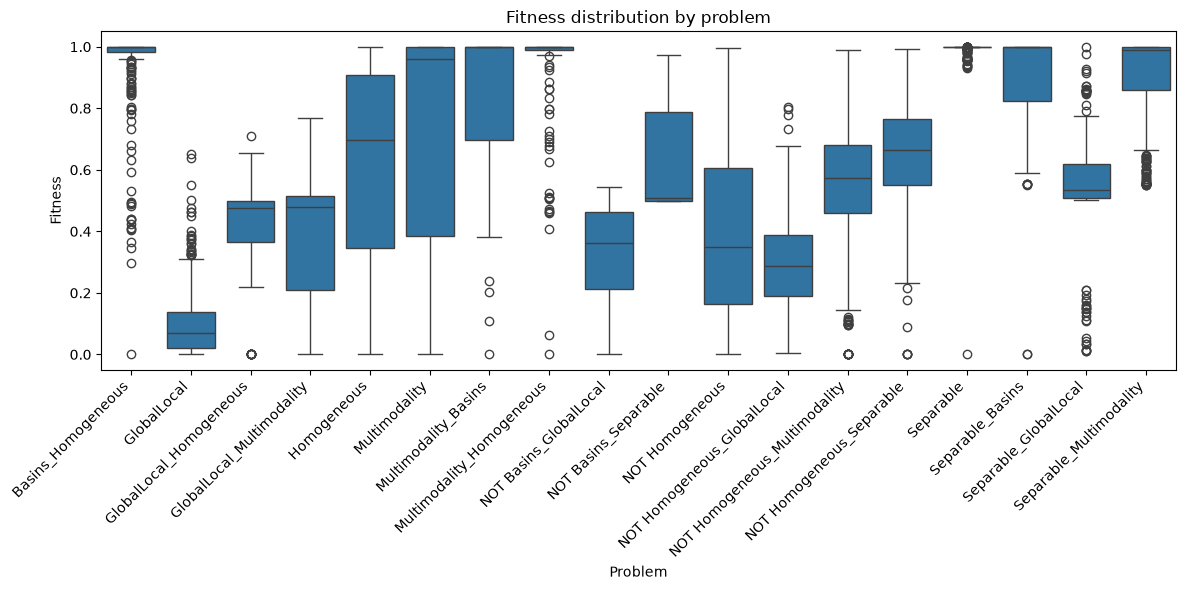

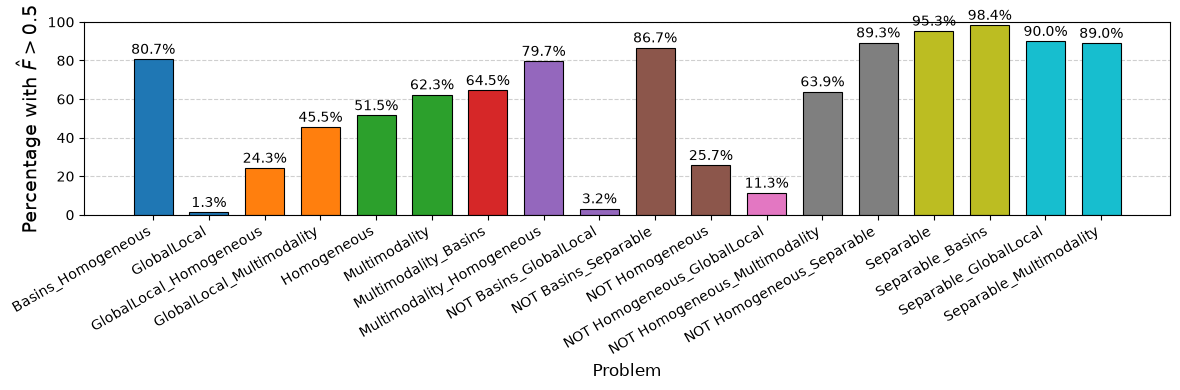

In [3]:
#plot_convergence(logger, metric="fitness", save=False, budget=100)
#plot_boxplot_fitness_hue(logger)

methods, problems = logger.get_methods_problems()
#sort problems by alphabetical order
problems = sorted(problems)

dfs = []
for problem in problems:
    data = logger.get_problem_data(problem_name=problem)
    data = data[data['fitness'] < 1.0001]
    # print if the length of the data is smaller than 11
    if len(data) < 11:
        print(f"Skipped: Problem: {problem}, data points: {len(data)}")
    else:
        data = data.assign(problem_name=str(problem))
        dfs.append(data[["problem_name", "fitness"]])

if len(dfs) > 0:
    all_data = pd.concat(dfs, ignore_index=True)
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=all_data, x='problem_name', y='fitness', ax=ax)
    ax.set_title("Fitness distribution by problem")
    ax.set_xlabel("Problem")
    ax.set_ylabel("Fitness")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()  



    # now count the number of landscapes with a fitness above 0.75 per problem and show this as a bar plot
    counts = all_data[all_data['fitness'] > 0.5].groupby('problem_name').size() / all_data.groupby('problem_name').size() * 100  # percentage

    fig, ax = plt.subplots(figsize=(12, 4))

    # Generate colors from a colormap (tab10 has 10 distinct colors)
    colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))

    # Plot bars with reduced width
    bars = ax.bar(counts.index, counts.values, color=colors, width=0.7, edgecolor='black', linewidth=0.8)

    # Add labels and nicer style
    ax.set_xlabel("Problem", fontsize=12)
    ax.set_ylabel("Percentage with $\hat{F} > 0.5$", fontsize=14)
    ax.set_ylim(0, 100)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Rotate and align x labels
    plt.xticks(rotation=30, ha='right')

    # Optionally add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%", ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


Error processing problem NOT Basins_Multimodality: need at least one array to concatenate


/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Failed on problem Basins: perplexity (6) must be less than n_samples (2)


/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Failed on problem GlobalLocal_Basins: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='full'
Failed on problem GlobalLocal_Homogeneous: perplexity (6) must be less than n_samples (3)


/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/pyth

Failed on problem NOT Basins: perplexity (6) must be less than n_samples (4)
Failed on problem NOT Basins_GlobalLocal: perplexity (6) must be less than n_samples (4)
Failed on problem NOT Basins_Multimodality: 0


/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/local/bodasap/BLADE/.venv/lib/pyth

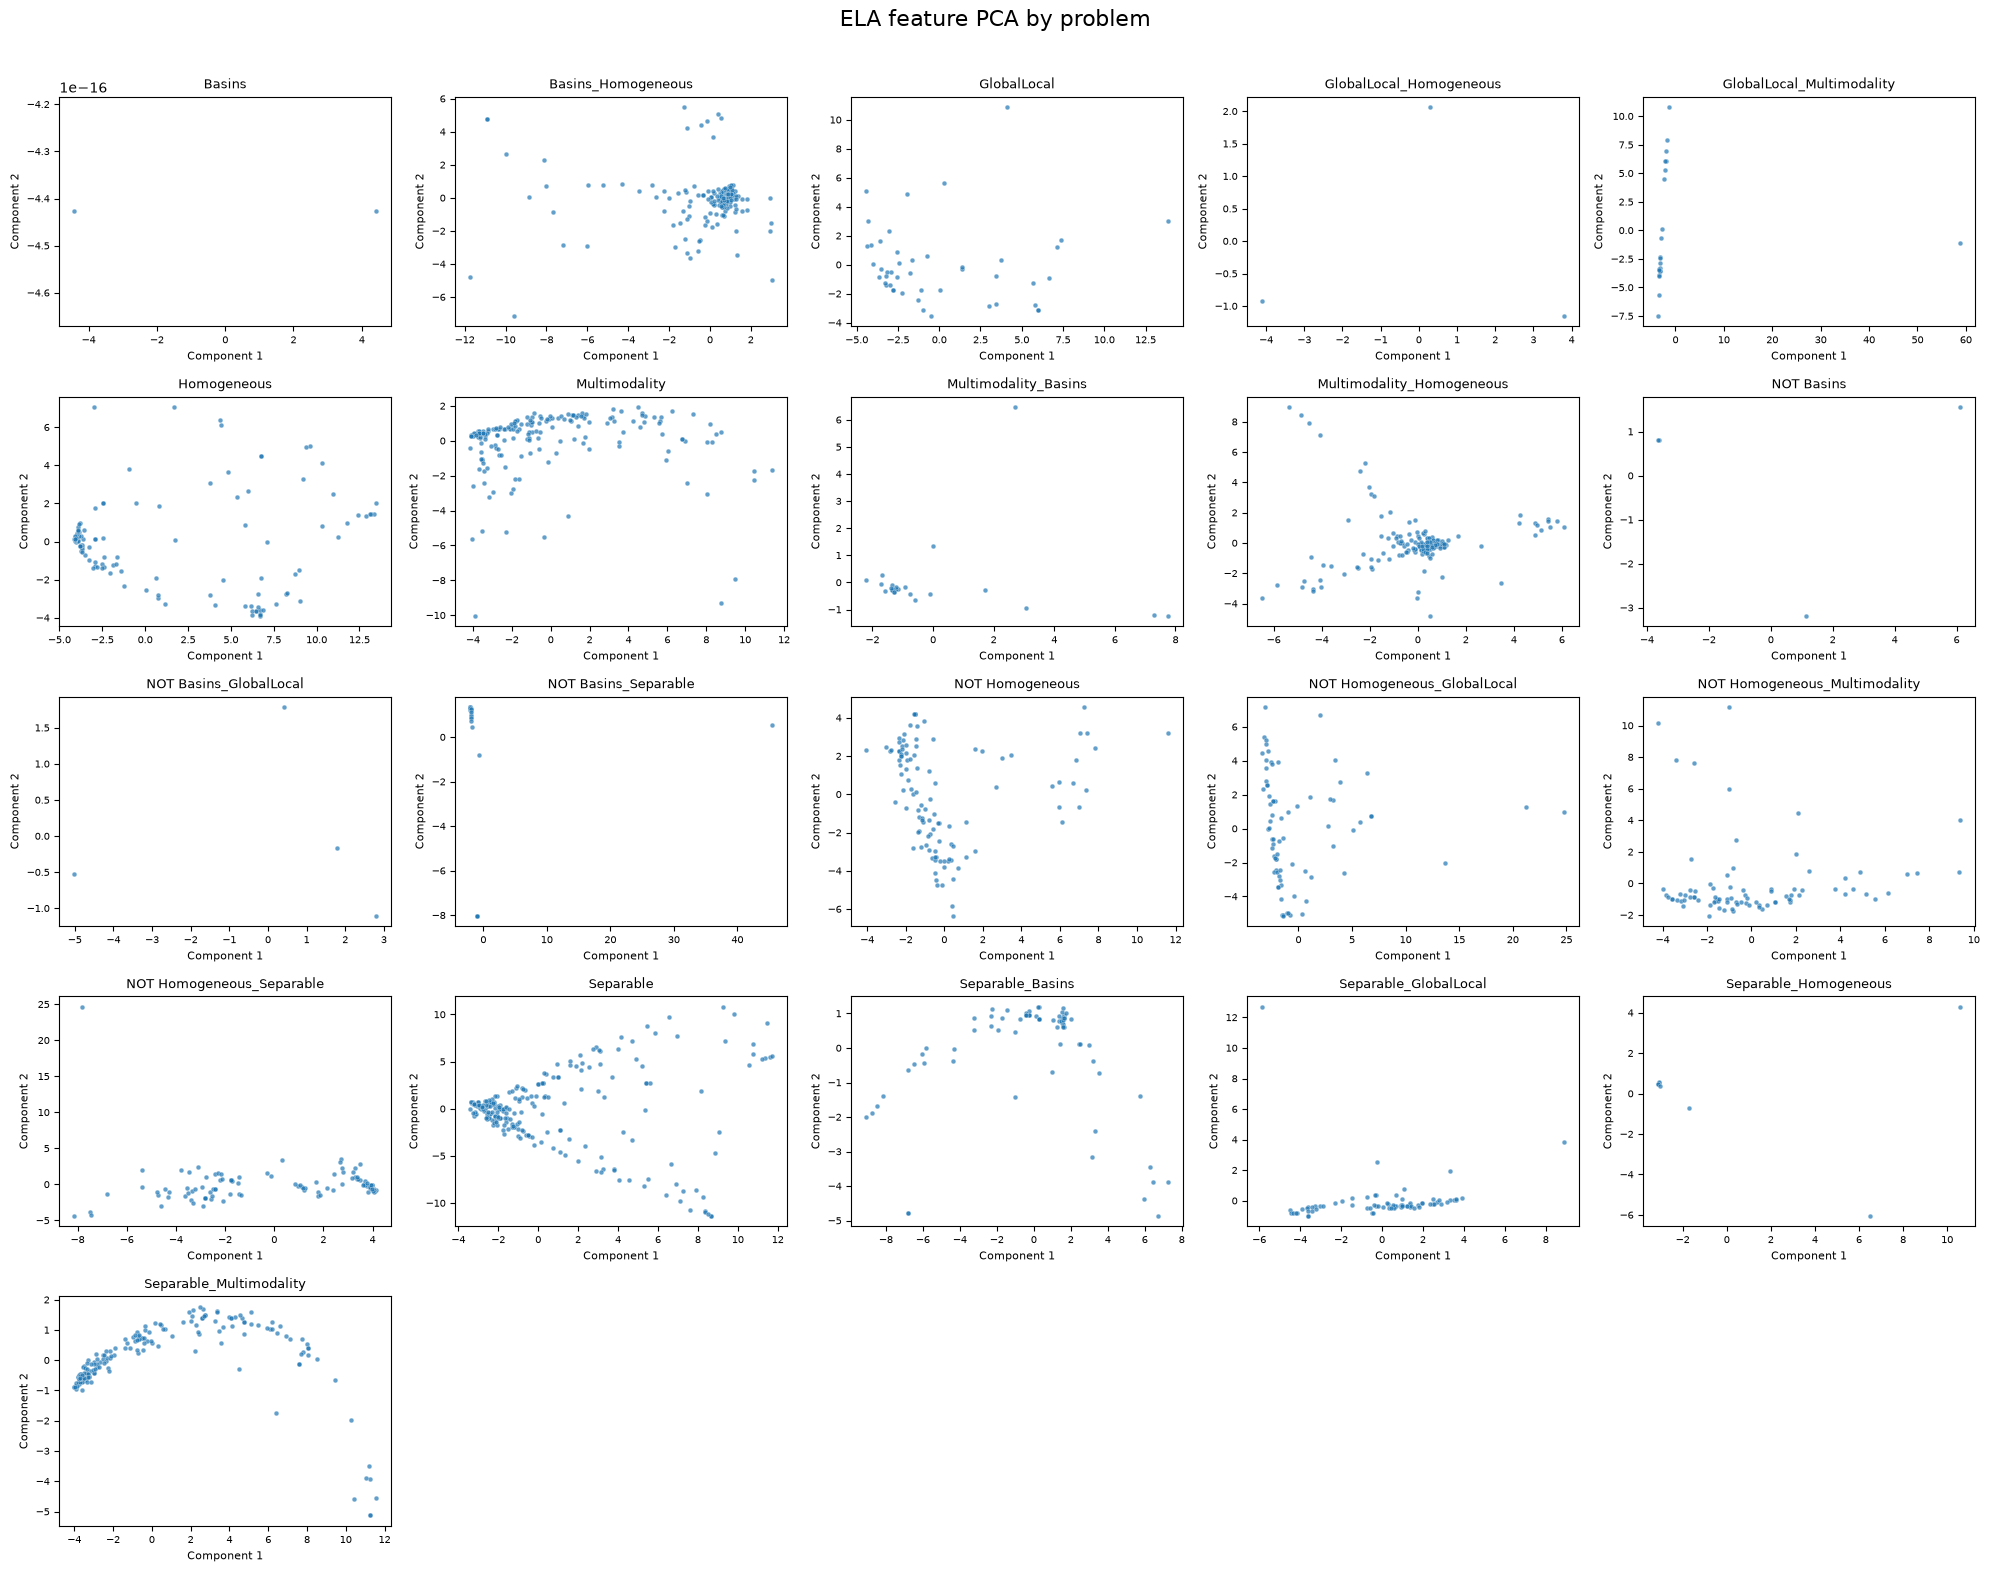

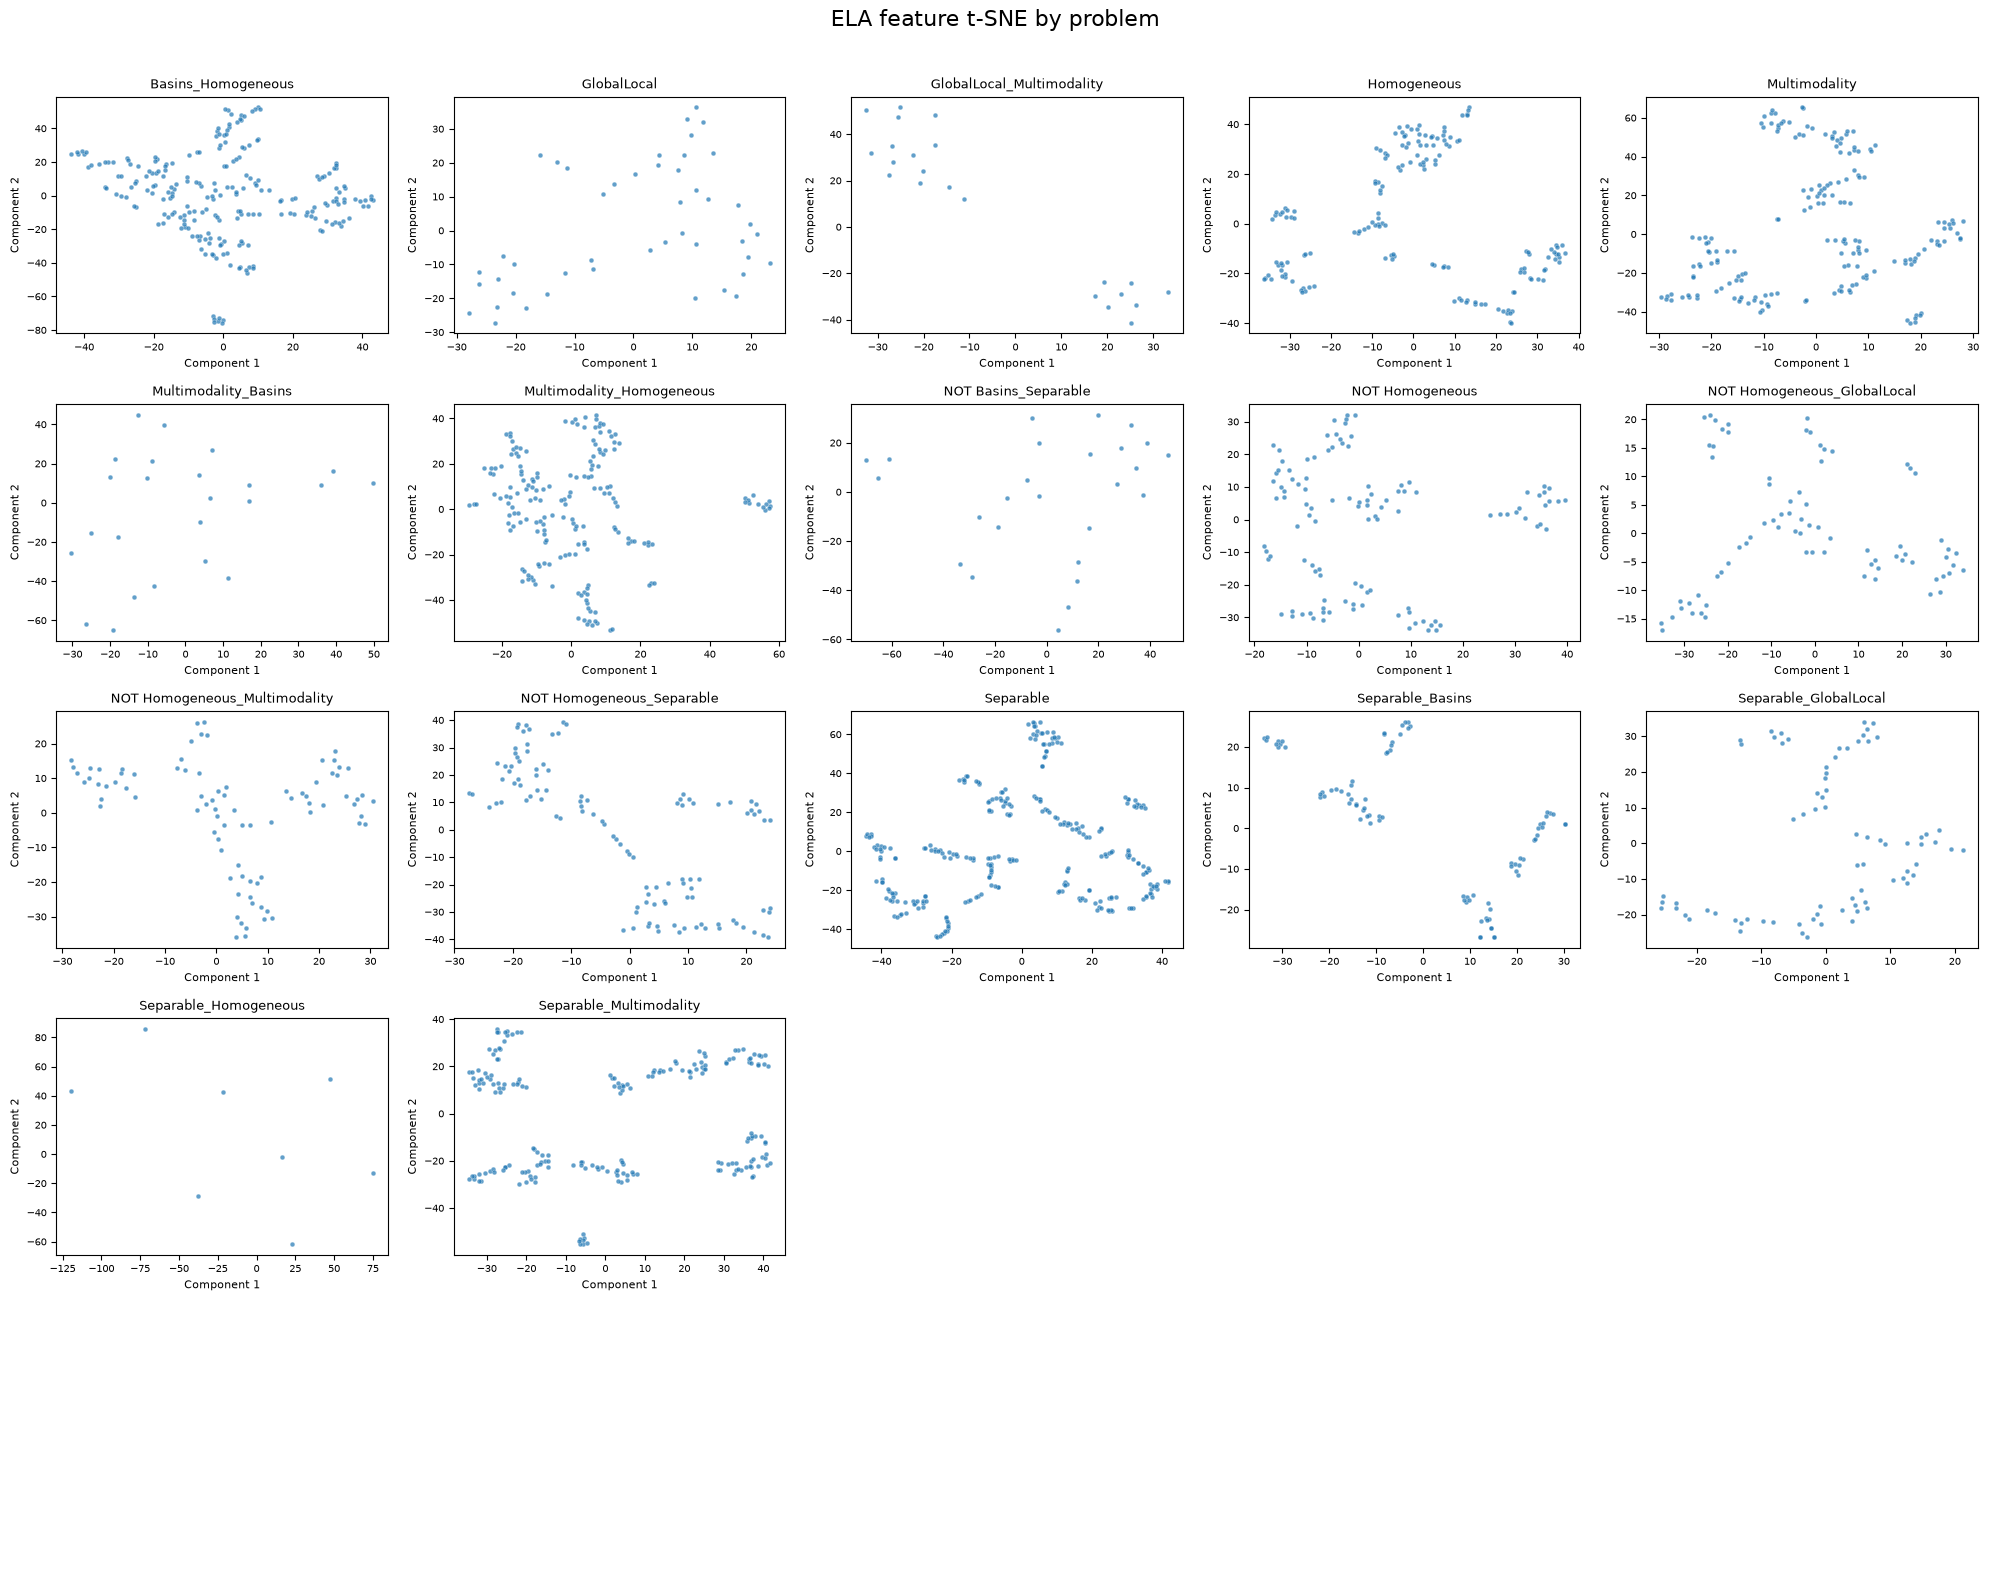

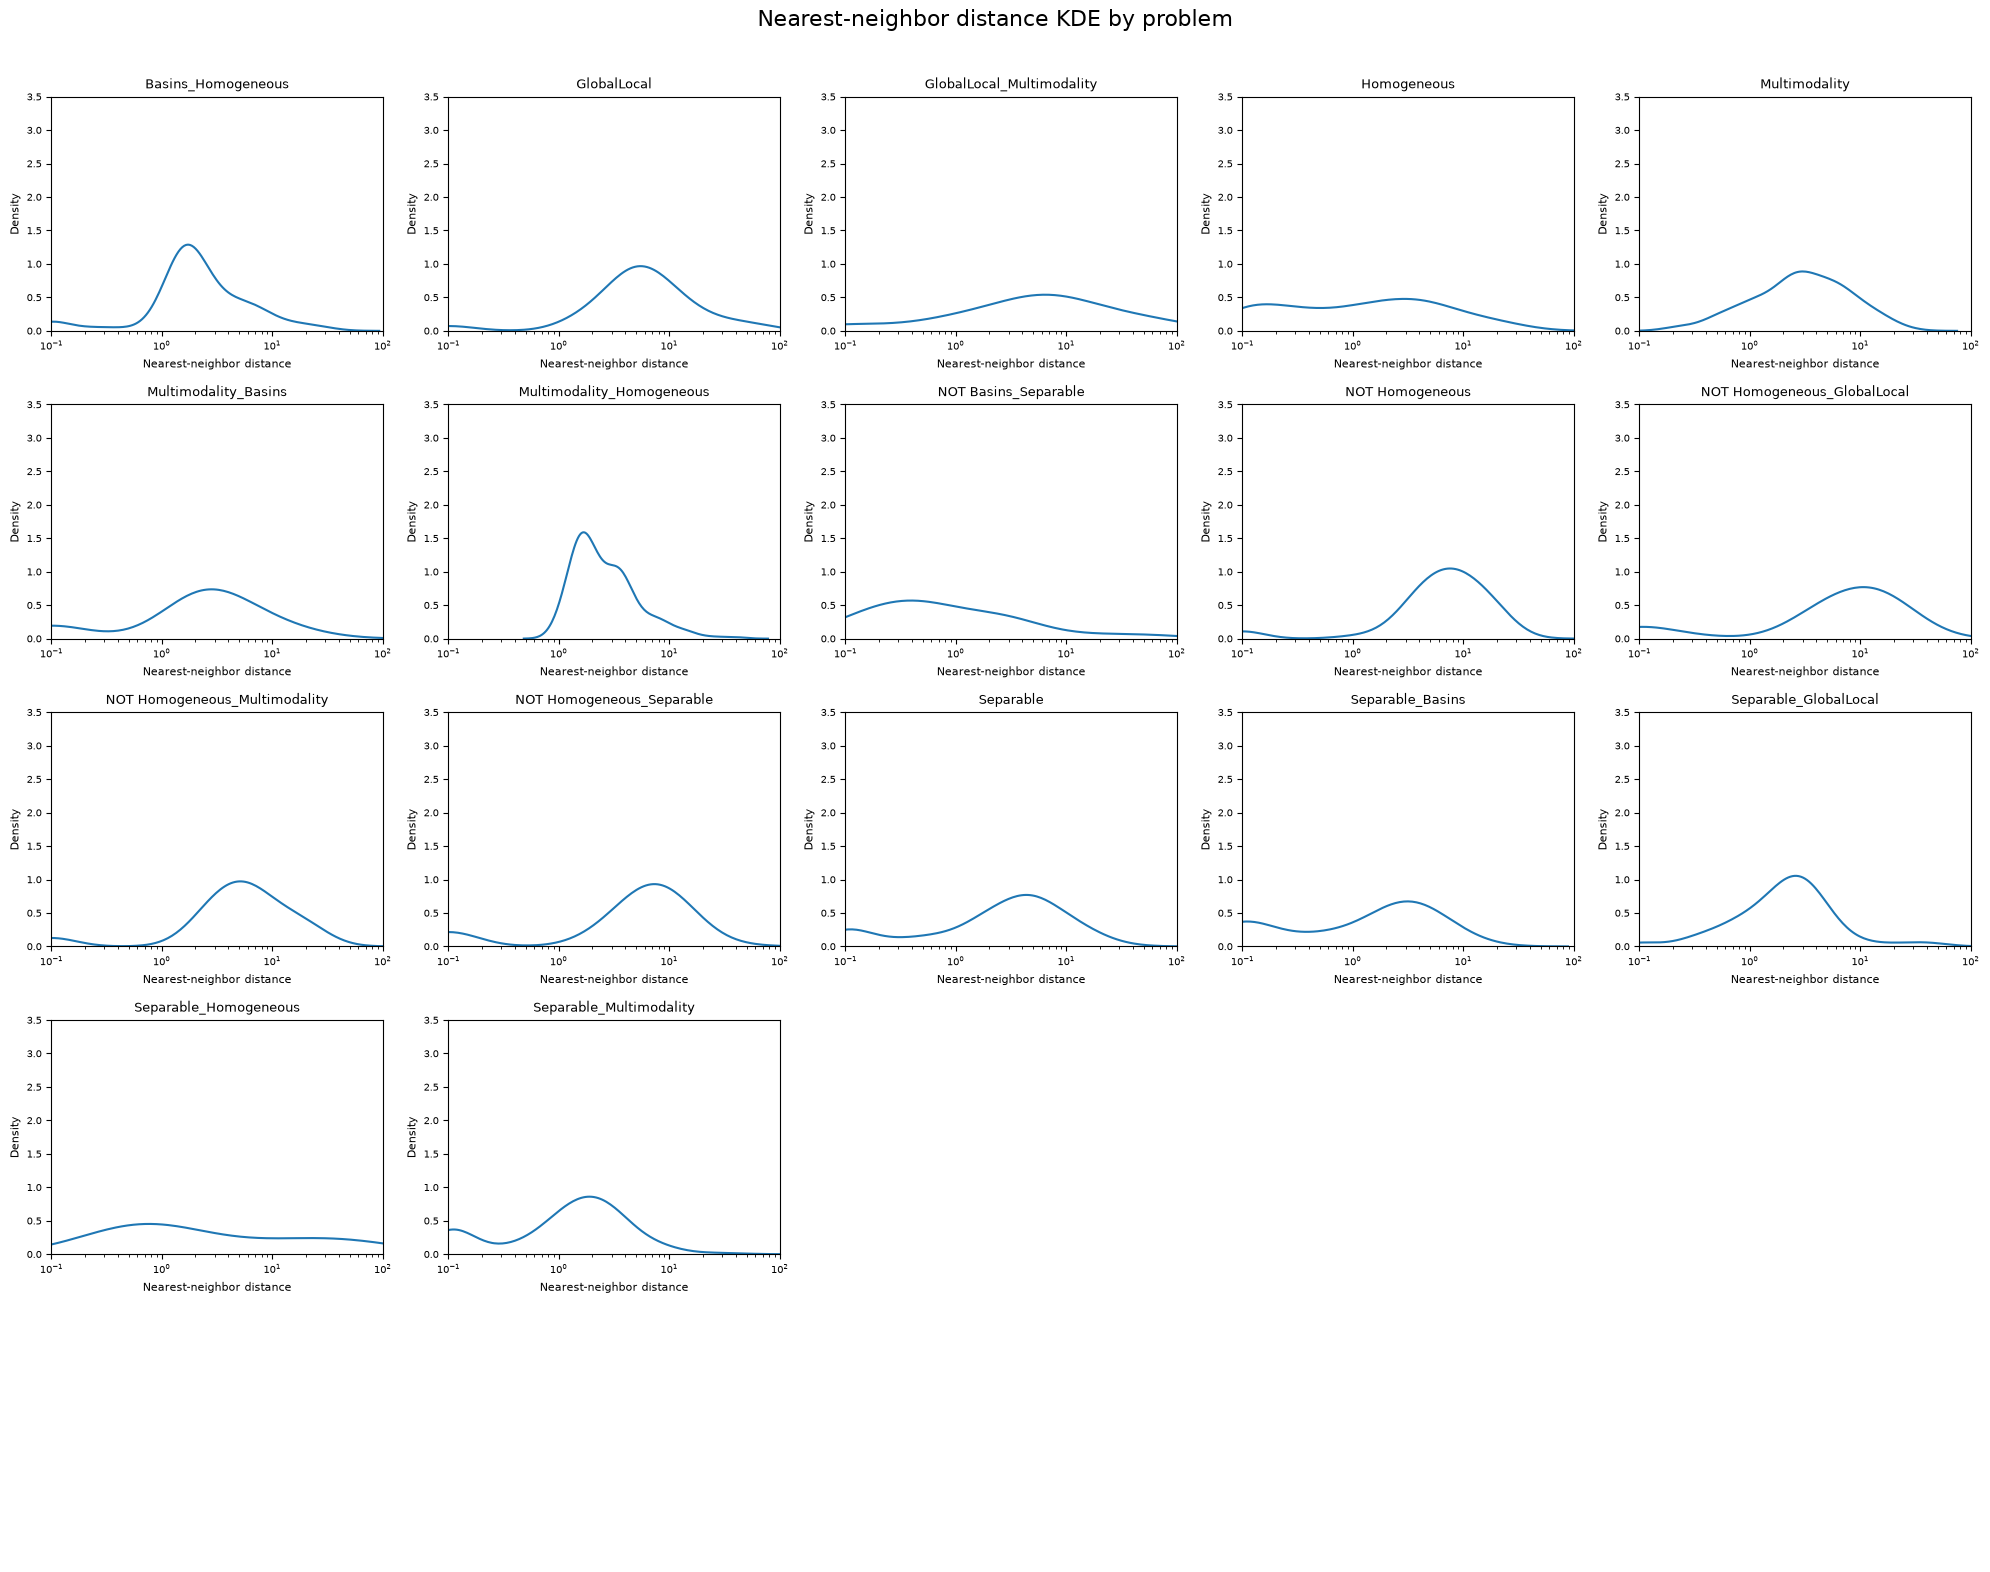

,Problem,"KDE Weighted Mean [0,100]"
0,Basins_Homogeneous,3.5873
1,GlobalLocal,10.0561
2,GlobalLocal_Multimodality,15.2272
3,Homogeneous,4.0325
4,Multimodality,4.5495
5,Multimodality_Basins,4.1811
6,Multimodality_Homogeneous,3.5468
7,NOT Basins_Separable,5.7374
8,NOT Homogeneous,8.7501
9,NOT Homogeneous_GlobalLocal,10.3166


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import joblib

def _plot_on_ax(row, ax, bounds=(-5, 5), res=300):
        ns = {}
        exec(row["code"], ns)
        f = getattr(ns[row["name"]](dim=2), "f")

        x = np.linspace(*bounds, res)
        y = np.linspace(*bounds, res)
        X, Y = np.meshgrid(x, y)
        Z = np.apply_along_axis(f, 1, np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)

        cs = ax.contour(X, Y, Z, levels=40, linewidths=0.6)
        #ax.clabel(cs, cs.levels[::2], inline=True, fontsize=6, fmt="%.2g")  # optional labels

        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{row['name']}", fontsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1.0)

def min_nearest_neighbor_distances(df, num_cols):
    """
    For each row, compute the distance to its nearest neighbor.
    Returns a Series aligned to df.index with NaN if there are fewer than 2 rows.
    """
    X = df[num_cols].astype(float).copy()
    out = pd.Series(np.nan, index=df.index, name="min_nearest_neighbor_dist")

    Xi = X.to_numpy()
    if len(Xi) < 2:
        return out

    dists = pairwise_distances(Xi, metric='cityblock')
    np.fill_diagonal(dists, np.inf)
    mins = dists.min(axis=1)
    out.loc[df.index] = np.where(mins < 0.1, 0.1, mins)

    return out


# Train a standard scaler
if True:
    all_ela_data = []

    for problem in problems:
        data = logger.get_problem_data(problem_name=problem)
        meta_df = pd.json_normalize(data['metadata'])

        expected_len = meta_df["ela_features"].apply(lambda v: len(v) if hasattr(v, '__len__') else 0).mode()[0]
        meta_df = meta_df[meta_df["ela_features"].apply(
            lambda v: hasattr(v, '__len__') and len(v) == expected_len
        )]
        meta_df["ela_features"] = meta_df["ela_features"].apply(
            lambda v: v[0] if isinstance(v, (list, tuple)) and len(v) == 1 else v
        )
        #remove nans and infs
        meta_df = meta_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["ela_features"])

        try:
            ela_mat = np.vstack(meta_df["ela_features"].values)
            all_ela_data.append(ela_mat)
        except Exception as e:
            print(f"Error processing problem {problem}: {e}")
            continue
    # combine into one big matrix
    all_ela_data = np.vstack(all_ela_data)

    # remove inf and NaN
    all_ela_data = np.where(np.isfinite(all_ela_data), all_ela_data, np.nan)
    mask = ~np.isnan(all_ela_data).any(axis=1)
    all_ela_data = all_ela_data[mask]

    # fit one scaler
    scaler = StandardScaler().fit(all_ela_data)
    joblib.dump(scaler, "ela_scaler.joblib")


pca_plots = []
tsne_plots = []
distance_plots = []
kde_mean_results = []

for problem in problems:
    data = logger.get_problem_data(problem_name=problem)

    # Get feature names from problem name
    feature_names = problem.split("_")[0:2]  # e.g. "basins_separable" -> ["basins", "separable"] and "basins" --> ["basins"]

    try:
        # Filter the best fitness values above 0.75 threshold
        #print(data["fitness"].describe())
        meta_df = pd.json_normalize(data['metadata'])

        if len(feature_names) == 1:
            index_mask = meta_df['score_' + feature_names[0] + '_2D'] > 0.5
        elif len(feature_names) == 2:
            index_mask = (meta_df['score_' + feature_names[0] + '_2D'] > 0.5) & (meta_df['score_' + feature_names[1] + '_2D'] > 0.5)
        else:
            raise ValueError(f"Unexpected number of features in problem name: {problem}")

        df_best = data.loc[index_mask].copy()
        meta_df = meta_df.loc[index_mask].copy()

        #print(meta_df.columns)

        expected_len = meta_df["ela_features"].apply(lambda v: len(v) if hasattr(v, '__len__') else 0).mode()[0]
        meta_df = meta_df[meta_df["ela_features"].apply(
            lambda v: hasattr(v, '__len__') and len(v) == expected_len
        )]

        meta_df["ela_features"] = meta_df["ela_features"].apply(lambda v: v[0] if isinstance(v, (list, tuple)) and len(v)==1 else v)

        # -- explode into separate numeric columns
        ela_mat = np.vstack(meta_df["ela_features"].values)
        ela_cols = [f"ela_{i}" for i in range(ela_mat.shape[1])]
        ela_df   = pd.DataFrame(ela_mat, columns=ela_cols, index=meta_df.index)

        df = pd.concat([df_best, ela_df], axis=1)
        #remove inf values from ela_cols dataframe
        df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=ela_cols)

        #print(df.columns)
        scaler = joblib.load(f"ela_scaler.joblib")
        
        #pc = TSNE(n_components=2, learning_rate='auto',
        #              init='random', perplexity=6).fit_transform(X_scaled)

        X_scaled = scaler.transform(df[ela_cols])
        pc = PCA(n_components=2).fit_transform(X_scaled)
        pca_plots.append((problem, pc))

        #X_scaled = scaler.transform(df[ela_cols])
        pc = TSNE(n_components=2, learning_rate='auto',
                    init='random', perplexity=6).fit_transform(X_scaled)
        tsne_plots.append((problem, pc))

        # Now get a numerical diversity metric on the ELA features
        df[ela_cols] = scaler.transform(df[ela_cols])
        min_d = min_nearest_neighbor_distances(df, ela_cols)
        distance_plots.append((problem, min_d.copy()))
        #print(min_d.head())
        #print(min_d.describe())
        
        from scipy.stats import gaussian_kde
        from scipy.integrate import quad
        vals = min_d.dropna().to_numpy()
        weighted_mean = np.nan
        if len(vals) > 1 and len(np.unique(vals)) > 1:
            kde = gaussian_kde(vals)
            # weighted_mean = quad(lambda x: x * kde(x), 0, 100)[0]

            weighted_mean = quad(lambda x: float(x * kde(x)[0]), 0, 100)[0]

        kde_mean_results.append((problem, weighted_mean))

    except Exception as e:
        print(f"Failed on problem {problem}: {e}")


def plot_embedding_grid(plot_data, title):
    rows, cols = 5, 5
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16))

    for ax, (problem, embedding) in zip(axes.ravel(), plot_data):
        sns.scatterplot(
            x=embedding[:, 0], y=embedding[:, 1],
            ax=ax, s=12, alpha=0.7, legend=False
        )
        ax.set_title(problem, fontsize=9)
        ax.set_xlabel("Component 1", fontsize=8)
        ax.set_ylabel("Component 2", fontsize=8)
        ax.tick_params(labelsize=7)

    for ax in axes.ravel()[len(plot_data):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()


def plot_distance_grid(plot_data, title, kind="hist"):
    rows, cols = 5, 5
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16))

    for ax, (problem, distances) in zip(axes.ravel(), plot_data):
        values = distances.dropna().to_numpy()
        plotted = len(values) > 0
        if kind == "hist" and plotted:
            sns.histplot(values, bins=100, log_scale=True, alpha=0.3,
                         kde=True, stat="density", ax=ax)
        elif len(values) > 1 and len(np.unique(values)) > 1:
            sns.kdeplot(values, log_scale=True, ax=ax)
        else:
            plotted = False

        ax.set_title(problem, fontsize=9)
        ax.set_xlabel("Nearest-neighbor distance", fontsize=8)
        ax.set_ylabel("Density", fontsize=8)
        ax.set_xlim(0.1, 100)
        ax.set_ylim(0, 3.5)
        ax.tick_params(labelsize=7)
        if not plotted:
            ax.text(0.5, 0.5, "No matching data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8)

    for ax in axes.ravel()[len(plot_data):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()


plot_embedding_grid(pca_plots, "ELA feature PCA by problem")
plot_embedding_grid(tsne_plots, "ELA feature t-SNE by problem")
plot_distance_grid(distance_plots, "Nearest-neighbor distance KDE by problem", kind="kde")

df_kde = pd.DataFrame(kde_mean_results, columns=["Problem", "KDE Weighted Mean [0,100]"])
df_kde = df_kde.dropna(subset=["KDE Weighted Mean [0,100]"])
# df_kde = df_kde.sort_values("KDE Weighted Mean [0,100]", ascending=False)

from IPython.display import display
display(df_kde.style.format({"KDE Weighted Mean [0,100]": "{:.4f}"}))